In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os

# Optional: suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
#==============================================================================
# CONFIGURATION - MODIFY THIS CELL
#==============================================================================

# Model type: 'SLIM', 'FULL', or 'MAX'
# SLIM: 3 outputs (x, y, cotB) - no uncertainties, no pull plots
# FULL: 4 outputs (x, y, cotA, cotB) + diagonal uncertainties
# MAX:  4 outputs + full covariance matrix
MODEL_TYPE = 'SLIM'  # Change this based on your models

# List of parquet files to compare (add/remove as needed)
parquet_files = [
    '/depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/2bit_optimized_parquets/2t-Mlp_Slim-2bit_optimized-34c2da80-vars.parquet',
    #'/depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/2bit_optimized_parquets/2t-Conv2D_Slim-2bit_optimized-vars_optimized.parquet',
    '/depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/outer_parquets/2t-QMlp_Slim-2bit_optimized-392456de-hls4ml-vars.parquet',
    #'/depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/2bit_optimized_parquets/2t-Conv2D_Slim-2bit_optimized-34c2da80-vars.parquet',
    #'/depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/2bit_optimized_parquets/2t-Conv1D_Slim-2bit_optimized-03cc0f27-vars.parquet',
]

# Labels for each file (must match length of parquet_files)
labels = [
    #'MLP-Slim (2t, 2-bit)',
    'mlp',  #Conv1D-Slim (2t, 2-bit)
    'hls4ml Mlp', #Conv1D-Slim (2t, 2-bit)
]

# Colors for each file (must match length of parquet_files)
colors = [
    'red',
    'orange', 
    #'green',
]

# Edge colors (for uncertainty bands) - set same as colors or different
edgecolors = [
    'red',
    'orange',
    #'green',
]

# Hatch patterns for uncertainty bands (helps distinguish overlapping bands)
# Options: '/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*', None
hatches = [
    None,      # solid fill
    'x',       # cross hatch
    #'-',       # horizontal lines
]

#==============================================================================
# SCALING FACTORS - Convert normalized values to physical units
#==============================================================================
# These convert from normalized NN output to physical units
# x, y -> micrometers (μm)
# alpha, beta -> will be converted to degrees via cotangent

ScalingFactor_x = 122.89689703635774      # x normalization factor
ScalingFactor_y = 30.903849401109394      # y normalization factor  
ScalingFactor_alpha = 6.560914919886437   # cotA normalization factor
ScalingFactor_beta = 1.917222249583349    # cotB normalization factor

#==============================================================================
# PLOT SETTINGS
#==============================================================================
figsize_residuals = (15, 10)  # For 2x2 grid (FULL/MAX)
figsize_residuals_slim = (18, 5)  # For 1x3 grid (SLIM)
figsize_pulls = (15, 10)  # For 2x2 pull plots

# Output directory for saved figures (set to None to not save)
output_dir = None  # e.g., './plots/' or None

# Figure DPI for saving
save_dpi = 300

In [3]:
#==============================================================================
# LOAD DATA
#==============================================================================

# Validate configuration
assert len(parquet_files) == len(labels) == len(colors), \
    "parquet_files, labels, and colors must have the same length!"

# Load all dataframes
dataframes = []
for i, fpath in enumerate(parquet_files):
    print(f"Loading [{i+1}/{len(parquet_files)}]: {fpath}")
    df = pd.read_parquet(fpath)
    dataframes.append(df)
    print(f"  -> {len(df)} events, columns: {list(df.columns)}")

print(f"\nLoaded {len(dataframes)} files successfully.")

# Quick check for expected columns
expected_cols_slim = ['x', 'y', 'cotB', 'xtrue', 'ytrue', 'cotBtrue']
expected_cols_full = expected_cols_slim + ['cotA', 'cotAtrue', 'sigmax', 'sigmay', 'sigmacotA', 'sigmacotB']

if MODEL_TYPE == 'SLIM':
    for i, df in enumerate(dataframes):
        missing = [c for c in expected_cols_slim if c not in df.columns]
        if missing:
            print(f"WARNING: File {i} missing columns: {missing}")
else:
    for i, df in enumerate(dataframes):
        missing = [c for c in expected_cols_full if c not in df.columns]
        if missing:
            print(f"WARNING: File {i} missing columns: {missing}")

Loading [1/2]: /depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/2bit_optimized_parquets/2t-Mlp_Slim-2bit_optimized-34c2da80-vars.parquet
  -> 108222 events, columns: ['x', 'y', 'cotB', 'xtrue', 'ytrue', 'cotBtrue', 'residuals_x', 'residuals_y', 'residuals_cotB']
Loading [2/2]: /depot/cms/private/users/kuang14/Smart_Pixel/input_digi_pipeline/outer_parquets/2t-QMlp_Slim-2bit_optimized-392456de-hls4ml-vars.parquet
  -> 108222 events, columns: ['xtrue', 'ytrue', 'cotBtrue', 'x', 'y', 'cotB', 'residuals_x', 'residuals_y', 'residuals_cotB']

Loaded 2 files successfully.


In [4]:
#==============================================================================
# HELPER FUNCTIONS
#==============================================================================

pi = 3.14159265359

def inverse_cot(cota):
    """Convert cotangent to angle in radians (0 to pi)."""
    a = np.arctan(1.0 / cota)
    a = np.array(a)  # Ensure it's an array
    a[np.where(a < 0)] = a[np.where(a < 0)] + pi
    return a

def gauss(x, A, mu, sigma):
    """Gaussian function for fitting pull distributions."""
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))


def residual_plot(ax, thisdf, var1, var2, name, color, label=None, 
                  scaling=1.0, alpha=0.2, slim=False, edgecolor=None, hatch=None):
    """
    Plot residuals (true - predicted) vs true value for position variables.
    
    Parameters:
    -----------
    ax : matplotlib axis
    thisdf : DataFrame with predictions
    var1 : str, column name for true values (e.g., 'xtrue')
    var2 : str, column name for predicted values (e.g., 'x')
    name : str, display name for axis labels
    color : str, color for points and fill
    label : str, legend label
    scaling : float, factor to convert to physical units
    alpha : float, transparency for uncertainty band
    slim : bool, if True, don't plot uncertainty bands
    edgecolor : str, edge color for uncertainty band
    hatch : str, hatch pattern for uncertainty band
    """
    nbins = 50
    
    # Scale values
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    step = 1.0 * (xmax - xmin) / nbins
    
    # Plot scatter with binned means
    sns.regplot(x=var1_scaled, y=residual_scaled, 
                x_bins=np.linspace(xmin, xmax, nbins), 
                fit_reg=None, marker='.', ax=ax, color=color, label=label)
    
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    # Store residuals for later use
    thisdf['residual' + var2] = residual_scaled
    
    # Compute uncertainty bands if not slim
    if not slim:
        means = []
        upbar = []
        downbar = []
        
        for i in range(nbins):
            mask = (var1_scaled > xmin + i * step) & (var1_scaled < xmin + (i + 1) * step)
            bin_residuals = thisdf['residual' + var2][mask]
            bin_sigma = thisdf['sigma' + var2][mask] * scaling
            
            mean_val = np.mean(bin_residuals) if len(bin_residuals) > 0 else np.nan
            means.append(mean_val)
            upbar.append(mean_val + np.mean(bin_sigma) if len(bin_sigma) > 0 else np.nan)
            downbar.append(mean_val - np.mean(bin_sigma) if len(bin_sigma) > 0 else np.nan)
        
        ax.fill_between(x=np.linspace(xmin, xmax, nbins), y1=upbar, y2=downbar,
                        alpha=alpha, color=color, edgecolor=edgecolor, hatch=hatch)


def residual_plot_deg(ax, thisdf, var1, var2, name, color, label=None,
                      scaling=1.0, alpha=0.2, slim=False, edgecolor=None, hatch=None):
    """
    Plot residuals for angular variables (cotA, cotB) converted to degrees.
    
    Same parameters as residual_plot, but handles cotangent->degree conversion.
    """
    # For non-cotangent variables, use regular residual plot
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, color, label, 
                      scaling, alpha, slim, edgecolor, hatch)
        return
    
    # Convert cotangent to angle in degrees
    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling) * 180 / pi
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling) * 180 / pi
    
    # Compute angle uncertainties if not slim
    if not slim:
        # Propagate uncertainty through cotangent->angle conversion
        thisdf['angleup'] = abs(
            inverse_cot((thisdf[var2].values + thisdf['sigma' + var2].values) * scaling) * 180 / pi 
            - thisdf['angle']
        )
        thisdf['angledown'] = abs(
            inverse_cot((thisdf[var2].values - thisdf['sigma' + var2].values) * scaling) * 180 / pi 
            - thisdf['angle']
        )
    
    var1_col = 'angletrue'
    var2_col = 'angle'
    
    nbins = 50
    xmin = np.min(thisdf[var1_col])
    xmax = np.max(thisdf[var1_col])
    step = 1.0 * (xmax - xmin) / nbins
    
    # Compute residuals
    thisdf['residual' + var2_col] = thisdf[var1_col] - thisdf[var2_col]
    
    # Plot scatter with binned means
    sns.regplot(x=thisdf[var1_col], y=thisdf['residual' + var2_col],
                x_bins=np.linspace(xmin, xmax, nbins),
                fit_reg=None, marker='.', ax=ax, color=color, label=label)
    
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    # Compute uncertainty bands if not slim
    if not slim:
        means = []
        upbar = []
        downbar = []
        
        for i in range(nbins):
            mask = (thisdf[var1_col] > xmin + i * step) & (thisdf[var1_col] < xmin + (i + 1) * step)
            bin_residuals = thisdf['residual' + var2_col][mask]
            
            mean_val = np.mean(bin_residuals) if len(bin_residuals) > 0 else np.nan
            means.append(mean_val)
            upbar.append(mean_val + np.mean(thisdf['angleup'][mask]) if mask.sum() > 0 else np.nan)
            downbar.append(mean_val - np.mean(thisdf['angledown'][mask]) if mask.sum() > 0 else np.nan)
        
        ax.fill_between(x=np.linspace(xmin, xmax, nbins), y1=upbar, y2=downbar,
                        alpha=alpha, color=color, edgecolor=edgecolor, hatch=hatch)


def pull_plot(ax, data, name, color, label=None):
    """
    Plot pull distribution (residual / uncertainty) with Gaussian fit.
    
    Parameters:
    -----------
    ax : matplotlib axis
    data : array-like, pull values (residual / sigma)
    name : str, name for x-axis label
    color : str, histogram color
    label : str, legend label
    
    Returns:
    --------
    dict with fitted mu and sigma
    """
    # Plot histogram
    h = ax.hist(data, bins=np.linspace(-5, 5, 100), histtype='step', 
                label=label, color=color, linewidth=1.5)
    
    ax.set_xlabel(name)
    ax.set_yscale('log')
    ax.axvline(x=0, alpha=0.3, ls='dashed', color='gray')
    
    # Fit Gaussian
    ydata = h[0]
    xdata = h[1][:-1] + (h[1][1] - h[1][0]) / 2  # bin centers
    
    try:
        # Initial guess
        p0 = [np.max(ydata), 0, 1]
        pars, cov = curve_fit(gauss, xdata, ydata, p0=p0, maxfev=5000)
        
        # Plot fit
        xbins = np.linspace(-5, 5, 200)
        ax.plot(xbins, gauss(xbins, pars[0], pars[1], pars[2]), 
                color=color, linestyle='--', alpha=0.7)
        
        mu, sigma = pars[1], abs(pars[2])
    except:
        mu, sigma = np.nan, np.nan
    
    return {'mu': mu, 'sigma': sigma}

In [5]:
#==============================================================================
# RESIDUAL PLOTS - FULL/MAX (2x2 grid: x, y, α, β)
#==============================================================================

if MODEL_TYPE in ['FULL', 'MAX']:
    fig, axes = plt.subplots(2, 2, figsize=figsize_residuals)
    
    is_slim = False  # FULL/MAX have uncertainties
    
    # X residuals
    for i, df in enumerate(dataframes):
        residual_plot(axes[0, 0], df.copy(), 'xtrue', 'x', 
                      name=r'$x$ [$\mu$m]', 
                      color=colors[i], label=labels[i],
                      edgecolor=edgecolors[i], hatch=hatches[i],
                      scaling=ScalingFactor_x, slim=is_slim)
    axes[0, 0].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[0, 0].set_title(r'$x$ residuals + uncertainties')
    axes[0, 0].legend(loc='upper left', fontsize=9)
    
    # Y residuals
    for i, df in enumerate(dataframes):
        residual_plot(axes[0, 1], df.copy(), 'ytrue', 'y',
                      name=r'$y$ [$\mu$m]',
                      color=colors[i], label=labels[i],
                      edgecolor=edgecolors[i], hatch=hatches[i],
                      scaling=ScalingFactor_y, slim=is_slim)
    axes[0, 1].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[0, 1].set_title(r'$y$ residuals + uncertainties')
    axes[0, 1].legend(loc='upper left', fontsize=9)
    
    # Alpha residuals
    for i, df in enumerate(dataframes):
        residual_plot_deg(axes[1, 0], df.copy(), 'cotAtrue', 'cotA',
                          name=r'$\alpha$ [deg]',
                          color=colors[i], label=labels[i],
                          edgecolor=edgecolors[i], hatch=hatches[i],
                          scaling=ScalingFactor_alpha, slim=is_slim)
    axes[1, 0].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[1, 0].set_title(r'$\alpha$ residuals + uncertainties')
    axes[1, 0].legend(loc='upper left', fontsize=9)
    
    # Beta residuals
    for i, df in enumerate(dataframes):
        residual_plot_deg(axes[1, 1], df.copy(), 'cotBtrue', 'cotB',
                          name=r'$\beta$ [deg]',
                          color=colors[i], label=labels[i],
                          edgecolor=edgecolors[i], hatch=hatches[i],
                          scaling=ScalingFactor_beta, slim=is_slim)
    axes[1, 1].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[1, 1].set_title(r'$\beta$ residuals + uncertainties')
    axes[1, 1].legend(loc='lower right', fontsize=9)
    
    fig.tight_layout()
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, f'residuals_{MODEL_TYPE}.png'), 
                    dpi=save_dpi, bbox_inches='tight')
        print(f"Saved: {output_dir}/residuals_{MODEL_TYPE}.png")
    
    plt.show()
else:
    print("Skipping FULL/MAX residual plot (MODEL_TYPE is SLIM)")

Skipping FULL/MAX residual plot (MODEL_TYPE is SLIM)


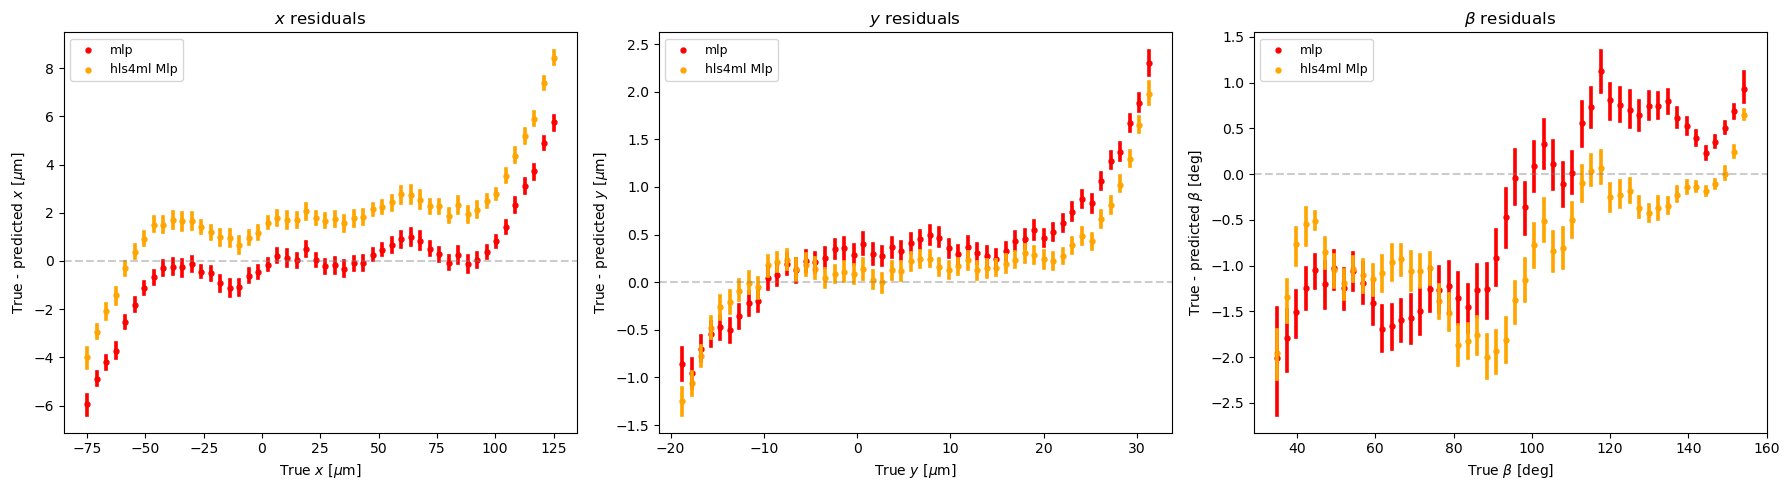

In [6]:
#==============================================================================
# RESIDUAL PLOTS - SLIM (1x3 grid: x, y, β only)
#==============================================================================

if MODEL_TYPE == 'SLIM':
    fig, axes = plt.subplots(1, 3, figsize=figsize_residuals_slim)
    
    is_slim = True  # SLIM has no uncertainties
    
    # X residuals
    for i, df in enumerate(dataframes):
        residual_plot(axes[0], df.copy(), 'xtrue', 'x',
                      name=r'$x$ [$\mu$m]',
                      color=colors[i], label=labels[i],
                      scaling=ScalingFactor_x, slim=is_slim)
    axes[0].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[0].set_title(r'$x$ residuals')
    axes[0].legend(loc='upper left', fontsize=9)
    
    # Y residuals
    for i, df in enumerate(dataframes):
        residual_plot(axes[1], df.copy(), 'ytrue', 'y',
                      name=r'$y$ [$\mu$m]',
                      color=colors[i], label=labels[i],
                      scaling=ScalingFactor_y, slim=is_slim)
    axes[1].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[1].set_title(r'$y$ residuals')
    axes[1].legend(loc='upper left', fontsize=9)
    
    # Beta residuals (no alpha for SLIM)
    for i, df in enumerate(dataframes):
        residual_plot_deg(axes[2], df.copy(), 'cotBtrue', 'cotB',
                          name=r'$\beta$ [deg]',
                          color=colors[i], label=labels[i],
                          scaling=ScalingFactor_beta, slim=is_slim)
    axes[2].axhline(y=0, alpha=0.4, ls='dashed', color='gray')
    axes[2].set_title(r'$\beta$ residuals')
    axes[2].legend(loc='best', fontsize=9)
    
    fig.tight_layout()
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, f'residuals_{MODEL_TYPE}.png'),
                    dpi=save_dpi, bbox_inches='tight')
        print(f"Saved: {output_dir}/residuals_{MODEL_TYPE}.png")
    
    plt.show()
else:
    print("Skipping SLIM residual plot (MODEL_TYPE is FULL or MAX)")

In [7]:
#==============================================================================
# PULL PLOTS - FULL/MAX only (2x2 grid)
#==============================================================================

if MODEL_TYPE in ['FULL', 'MAX']:
    fig, axes = plt.subplots(2, 2, figsize=figsize_pulls)
    
    # Store fit results for summary
    pull_results = {var: [] for var in ['x', 'y', 'cotA', 'cotB']}
    
    # We need to compute residuals first (they were stored in df during residual plotting)
    # Recompute here to be safe
    for i, df in enumerate(dataframes):
        # Compute residuals in normalized space for pull calculation
        df['residualsx'] = (df['xtrue'] - df['x']) * ScalingFactor_x
        df['residualsy'] = (df['ytrue'] - df['y']) * ScalingFactor_y
        df['residualscotA'] = (df['cotAtrue'] - df['cotA']) * ScalingFactor_alpha
        df['residualscotB'] = (df['cotBtrue'] - df['cotB']) * ScalingFactor_beta
    
    # X pull
    for i, df in enumerate(dataframes):
        pull_x = df['residualsx'] / (df['sigmax'] * ScalingFactor_x)
        result = pull_plot(axes[0, 0], pull_x, name='x pull', 
                          color=colors[i], label=labels[i])
        pull_results['x'].append(result)
    axes[0, 0].legend(loc='upper right', fontsize=8)
    axes[0, 0].set_ylim(0.5, None)
    
    # Y pull
    for i, df in enumerate(dataframes):
        pull_y = df['residualsy'] / (df['sigmay'] * ScalingFactor_y)
        result = pull_plot(axes[0, 1], pull_y, name='y pull',
                          color=colors[i], label=labels[i])
        pull_results['y'].append(result)
    axes[0, 1].legend(loc='upper right', fontsize=8)
    axes[0, 1].set_ylim(0.5, None)
    
    # cotA pull
    for i, df in enumerate(dataframes):
        pull_cotA = df['residualscotA'] / (df['sigmacotA'] * ScalingFactor_alpha)
        result = pull_plot(axes[1, 0], pull_cotA, name=r'cot$\alpha$ pull',
                          color=colors[i], label=labels[i])
        pull_results['cotA'].append(result)
    axes[1, 0].legend(loc='upper right', fontsize=8)
    axes[1, 0].set_ylim(0.5, None)
    
    # cotB pull
    for i, df in enumerate(dataframes):
        pull_cotB = df['residualscotB'] / (df['sigmacotB'] * ScalingFactor_beta)
        result = pull_plot(axes[1, 1], pull_cotB, name=r'cot$\beta$ pull',
                          color=colors[i], label=labels[i])
        pull_results['cotB'].append(result)
    axes[1, 1].legend(loc='upper right', fontsize=8)
    axes[1, 1].set_ylim(0.5, None)
    
    fig.suptitle(f'Pull Distributions ({MODEL_TYPE} models)', fontsize=12)
    fig.tight_layout()
    
    if output_dir:
        fig.savefig(os.path.join(output_dir, f'pulls_{MODEL_TYPE}.png'),
                    dpi=save_dpi, bbox_inches='tight')
        print(f"Saved: {output_dir}/pulls_{MODEL_TYPE}.png")
    
    plt.show()
    
    # Print summary table
    print("\n" + "="*70)
    print("PULL FIT SUMMARY (ideal: μ=0, σ=1)")
    print("="*70)
    print(f"{'Variable':<12} {'Model':<35} {'μ':>8} {'σ':>8}")
    print("-"*70)
    for var in ['x', 'y', 'cotA', 'cotB']:
        for i, label in enumerate(labels):
            r = pull_results[var][i]
            print(f"{var:<12} {label:<35} {r['mu']:>8.3f} {r['sigma']:>8.3f}")
        print("-"*70)
else:
    print("Skipping pull plots (MODEL_TYPE is SLIM - no uncertainties)")

Skipping pull plots (MODEL_TYPE is SLIM - no uncertainties)


In [8]:
#==============================================================================
# SUMMARY STATISTICS
#==============================================================================

print("="*80)
print("RESIDUAL SUMMARY STATISTICS")
print("="*80)

for i, df in enumerate(dataframes):
    print(f"\n[{labels[i]}]")
    print("-"*60)
    
    # X
    res_x = (df['xtrue'] - df['x']) * ScalingFactor_x
    print(f"  x:    mean = {res_x.mean():>8.4f} μm,  std = {res_x.std():>8.4f} μm")
    
    # Y
    res_y = (df['ytrue'] - df['y']) * ScalingFactor_y
    print(f"  y:    mean = {res_y.mean():>8.4f} μm,  std = {res_y.std():>8.4f} μm")
    
    # Alpha (if not SLIM)
    if MODEL_TYPE != 'SLIM' and 'cotAtrue' in df.columns:
        angle_true = inverse_cot(df['cotAtrue'].values * ScalingFactor_alpha) * 180 / pi
        angle_pred = inverse_cot(df['cotA'].values * ScalingFactor_alpha) * 180 / pi
        res_alpha = angle_true - angle_pred
        print(f"  α:    mean = {np.mean(res_alpha):>8.4f} deg, std = {np.std(res_alpha):>8.4f} deg")
    
    # Beta
    angle_true_b = inverse_cot(df['cotBtrue'].values * ScalingFactor_beta) * 180 / pi
    angle_pred_b = inverse_cot(df['cotB'].values * ScalingFactor_beta) * 180 / pi
    res_beta = angle_true_b - angle_pred_b
    print(f"  β:    mean = {np.mean(res_beta):>8.4f} deg, std = {np.std(res_beta):>8.4f} deg")

print("\n" + "="*80)

RESIDUAL SUMMARY STATISTICS

[mlp]
------------------------------------------------------------
  x:    mean =  -0.0763 μm,  std =   7.0298 μm
  y:    mean =   0.4356 μm,  std =   2.4349 μm
  β:    mean =  -0.2373 deg, std =   4.7808 deg

[hls4ml Mlp]
------------------------------------------------------------
  x:    mean =   1.8359 μm,  std =   7.2977 μm
  y:    mean =   0.2520 μm,  std =   2.2290 μm
  β:    mean =  -0.6658 deg, std =   3.5995 deg

